# Results Viewer

### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cr3bp import (
    create_earth_moon_system,
    plot_trajectory,
    decision_to_state0,
    evaluate,
    animate_trajectory,
    ciruclar_orbit_trajectory_moon,
    jacobi_integral,
    file_path
    )

### Initialize the System / Problem

In [2]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()

In [3]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

## Results

In [4]:
optimals = np.load(f"{file_path}/optimals_iteration3.npy")

In [5]:
print(optimals)

[3.96961565 3.02484418 0.07460938 0.72992717]


In [6]:
optimal_theta = optimals[0]
optimal_delta_v = optimals[1]
optimal_delta_v_angle = optimals[2]
optimal_tof = optimals[3]
print(f"Optimal Delta_v from Grid Search: {optimal_delta_v*em.v_star*1e-3:.4f} km/s")
print(f"Optimal Theta from Grid Search: {optimal_theta:.4f} rad")
print(f"Optimal Delta_v Angle from Grid Search: {optimal_delta_v_angle:.4f} rad")
print(f"Optimal Time of Flight from Grid Search: {optimal_tof * em.t_star / 86400:.4f} days")

Optimal Delta_v from Grid Search: 3.0990 km/s
Optimal Theta from Grid Search: 3.9696 rad
Optimal Delta_v Angle from Grid Search: 0.0746 rad
Optimal Time of Flight from Grid Search: 3.1697 days


In [7]:
print(f"Optimal Delta_v Angle: {optimal_delta_v_angle * 180 / np.pi:.2f} degrees")
print(f"Optimal Theta: {optimal_theta * 180 / np.pi:.2f} degrees")

Optimal Delta_v Angle: 4.27 degrees
Optimal Theta: 227.44 degrees


## Transition Trajectory

In [8]:
x0 = np.array(optimals)
state0 = decision_to_state0(em, x0, leo_alt_m)

In [9]:
tof = x0[3]
t_span = (0,tof)
n_points = 1000
#t_eval = np.linspace(0, tof, n_points)
t_eval = np.arange(0, tof, 1e-3) # Starts at 0, ends at tof, with a step of 1e-3 seconds
states, ts, sol = em.solve(state0, t_span, t_eval)
states_rocket_inertial = em.trajectory_rotating_to_inertial(states, t_eval)

In [10]:
constraint_value, objective_value = evaluate(em, x0, leo_alt_m=leo_alt_m, lmo_alt_m=lmo_alt_m)

### Plot

In [11]:
pos_f = states[:,-1][0:3]
#print(f"Rocket Final Pos in Rotating Frame (normalized units): {pos_f}")
print(f"Distance from moon : {1e-3*(constraint_value*em.l_star + lmo_alt_m):.0f} km")
print(f"Distance from LMO of 100 km : {constraint_value*em.l_star * 1e-3:.0f} km")
print(f"Total Delta_v required : {objective_value*em.v_star * 1e-3:.3f} km/s")

Distance from moon : 100 km
Distance from LMO of 100 km : -0 km
Total Delta_v required : 3.398 km/s


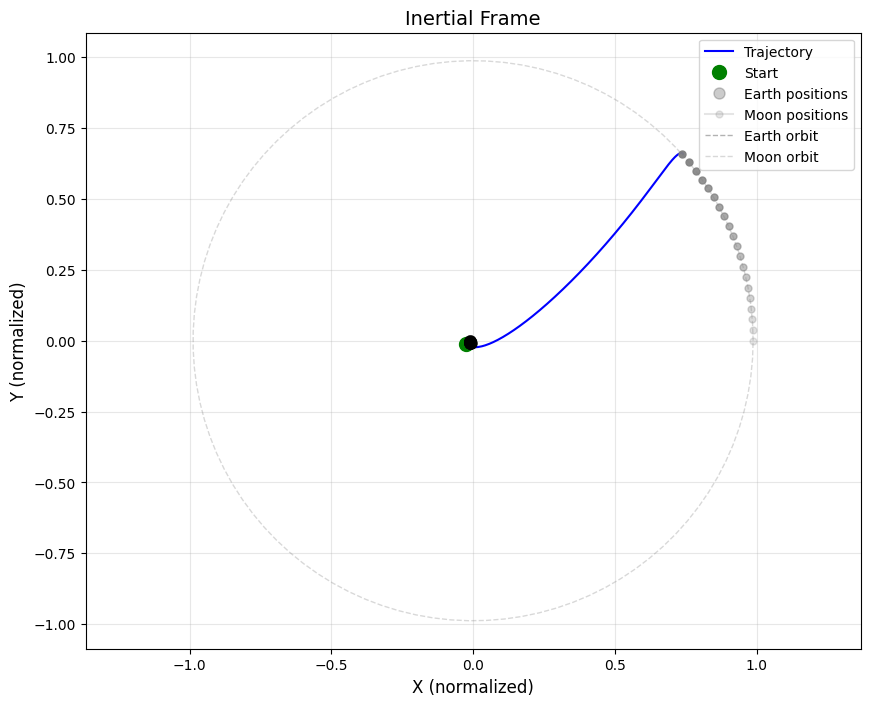

In [12]:
plot_trajectory(states, em.mu, t_eval, frame="Inertial")

## Low Lunar Orbit

In [13]:
moon_f = np.array([1-em.mu,0,0,0,0,0])
moon_f_inertial = em.rotating_to_inertial(moon_f,tof)

tof_llo = 1.5
t_eval_llo = np.arange(tof, tof+tof_llo, 1e-3) # Starts at the end of the previous trajectory, 
#ends at tof+tof_llo, with a step of 1e-3 seconds

states_llo_inertial = ciruclar_orbit_trajectory_moon(em, states_rocket_inertial[:,-1], moon_f_inertial, tof_llo, num_points=len(t_eval_llo))
states_llo_rotating = em.trajectory_inertial_to_rotating(states_llo_inertial, t_eval_llo)

### Plot

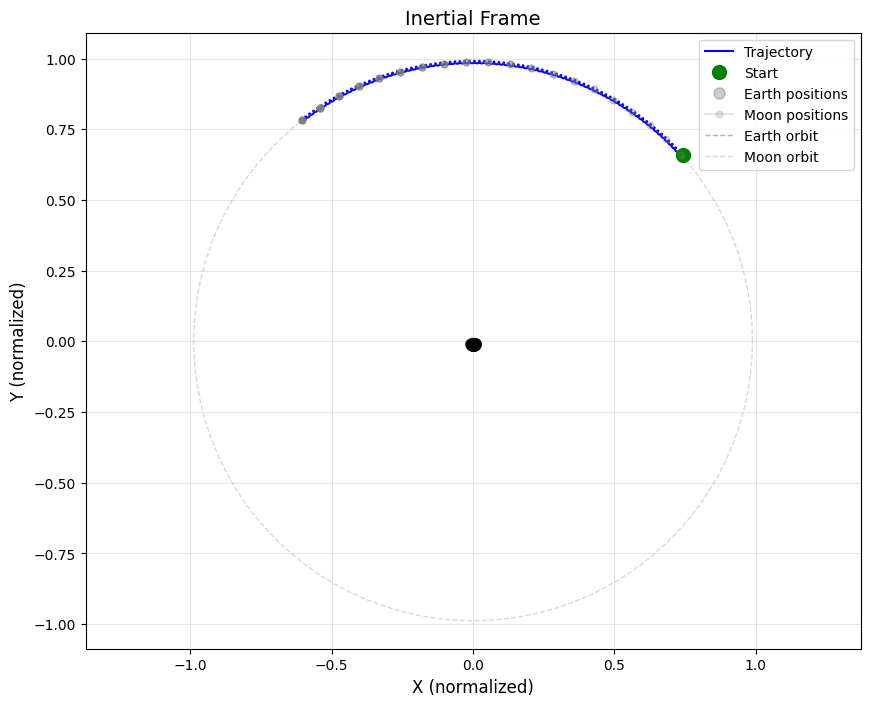

In [14]:
plot_trajectory(states_llo_rotating, em.mu, t_eval_llo, frame="Inertial")

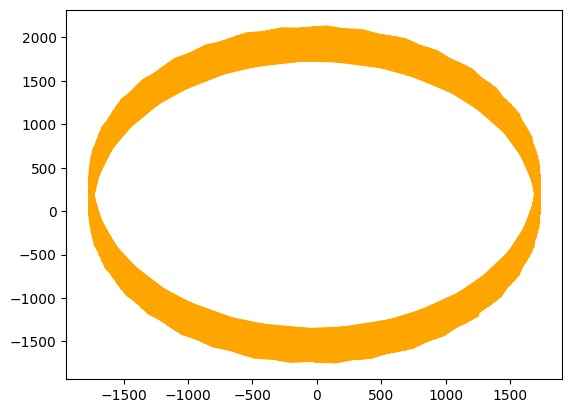

In [15]:
plt.plot(states_llo_rotating[0,:]*em.l_star*1e-3 - 379750, states_llo_rotating[1,:]*em.l_star*1e-3, label="LLMO Orbit", color="orange")

#### Check stability by integrating

In [16]:
state1 = states_llo_rotating[:,0]
print(state1)

[ 0.99115953 -0.00312981  0.         -0.00312981 -0.99115953  0.        ]


In [17]:
#t_eval = np.linspace(0, tof, n_points)
t_eval = np.arange(0, tof, 1e-3) # Starts at 0, ends at tof, with a step of 1e-3 seconds
states2, ts, sol = em.solve(state1, t_span, t_eval)

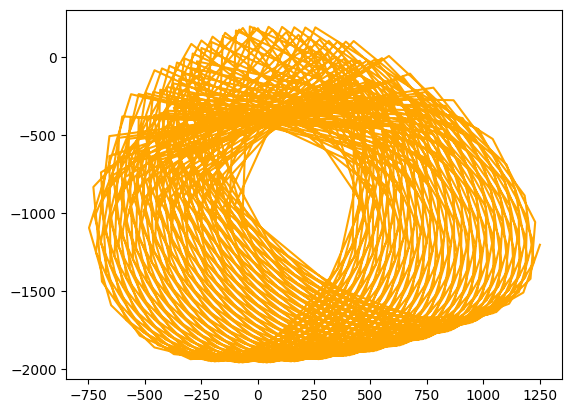

In [18]:
plt.plot(states2[0,:]*em.l_star*1e-3 - 379750, states2[1,:]*em.l_star*1e-3, label="LLMO Orbit", color="orange")

## Combine TLI and LMO

In [19]:
states_full = np.concatenate((states, states_llo_rotating), axis=1) # Concatenate the two trajectories along the time axis (columns)
t_full = np.arange(0, tof+tof_llo, 1e-3) # Starts at 0, ends at tof+tof_llo, with a step of 1e-3 seconds

### Plot

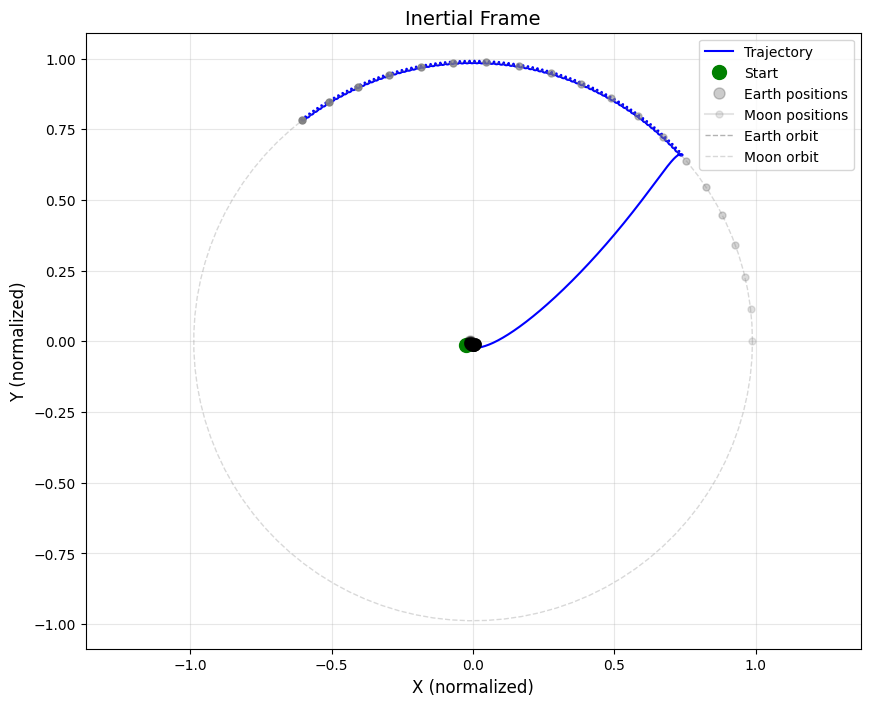

In [20]:
plot_trajectory(states_full, em.mu, t_full, frame="Inertial")

## Convergence Test

Use the Jacobi integral (constant of motion) to check the convergence of the integration

Min Jacobi Integral: 2.009531450896
max Jacobi Integral: 2.009531451015
Difference between max and min Jacobi Integral: 1.193996013171e-10
STD of Jacobi Integral: 3.915309497100e-12


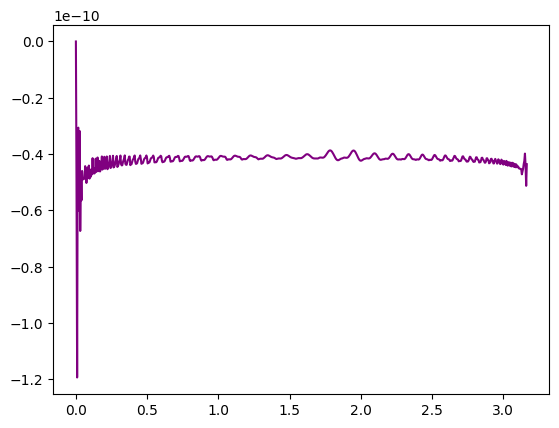

In [21]:
jacobi_integral_values = jacobi_integral(em, states)
plt.plot(t_eval*em.t_star/86400, jacobi_integral_values-jacobi_integral_values[0], label="Jacobi Integral", color="purple")
print(f"Min Jacobi Integral: {np.min(jacobi_integral_values):.12f}")
print(f"max Jacobi Integral: {np.max(jacobi_integral_values):.12f}")
diff = np.max(jacobi_integral_values) - np.min(jacobi_integral_values)
print(f"Difference between max and min Jacobi Integral: {diff:.12e}")
print(f"STD of Jacobi Integral: {np.std(jacobi_integral_values):.12e}")

## Load Dataset

In [ ]:
df = np.load(f"{file_path}/optimals_iteration3_df.npy", allow_pickle=True)
df = pd.DataFrame(df, columns=["theta", "delta_v", "delta_v_angle", "tof", "objective_value", "distance_to_lmo"])
df['distance_to_lmo'] = abs(df['distance_to_lmo'] * em.l_star * 1e-3)
df.sort_values(by='distance_to_lmo', inplace=True)
optimals = df.iloc[0][0:4].tolist()
print(df)

FileNotFoundError: [Errno 2] No such file or directory: 'grid_search_results_df.npy'

## Animate

In [ ]:
animate = 0
if animate == 1:
    anim = animate_trajectory(em, states_full, t_full, frame='inertial', trail_length=2000)
    from IPython.display import HTML
    HTML(anim.to_html5_video())
    anim.save('trajectory_animation.mp4', writer='ffmpeg', fps=30, dpi=150)